# HyDesign Battery Degradation Model — Tests & Visualisations

Demonstrates the complete battery degradation pipeline:

| Capability | Function |
|---|---|
| **1** Cycle extraction from SoC time series | `RFcount` — rainflow counting |
| **2** Per-cycle stress-based degradation | `Linear_Degfun` — Xu et al. (2016) |
| **3** Non-linear capacity-loss model | `degradation` |
| **4** Multi-battery replacement logic | `battery_replacement` |
| **5** Temperature-dependent capacity loss | `thermal_loss_of_storage` |

> All functions are defined inline to avoid the `openmdao` import chain.

In [1]:
import pickle                    # for loading reference test fixtures
import numpy as np               # array maths
import pandas as pd              # tabular data (rainflow DataFrame)
import scipy as sp               # scientific computing utilities (unused directly, but required by deps)
import rainflow                  # ASTM E1049 rainflow cycle-counting library
import matplotlib.pyplot as plt  # plotting
import matplotlib.gridspec as gridspec  # multi-panel figure layouts

from hydesign.examples import examples_filepath  # path to bundled example weather CSV files
from hydesign.tests.test_files import tfp        # path to reference pickle test fixtures

# ── Inline function definitions (mirrors hydesign/battery_degradation.py) ──

def RFcount(SoC):
    """Rainflow cycle counting on a SoC time series."""
    rf_df = pd.DataFrame(
        data=[[rng, mean, count, i_start, i_end]
              for rng, mean, count, i_start, i_end in rainflow.extract_cycles(SoC)],
        columns=['rng_', 'mean_', 'count_', 'i_start', 'i_end'])
    rf_df = rf_df.sort_values(by='i_start')
    return (rf_df.rng_.values, rf_df.mean_.values,
            rf_df.count_.values, rf_df.i_start.astype(int).values, rf_df)

def Linear_Degfun(rf_DoD, rf_SoC, rf_count, rf_i_start, avr_tem):
    """Per-cycle linear degradation (Xu et al., IEEE Trans. Smart Grid, 2016)."""
    kdelta1, kdelta2, kdelta3 = 1.4e5, -5.01e-1, -1.23e5
    ksigma, sigma_ref = 1.04, 0.5
    kT, Tref, kti = 6.93e-2, 293.15, 4.14e-10
    LLoC_hist = []
    for j in range(len(rf_DoD)):
        S_DoD = (kdelta1 * (rf_DoD[j] ** kdelta2 if rf_DoD[j] != 0 else 0) + kdelta3) ** (-1)# deeper cycle → more damage
        S_time = kti * rf_i_start[j] # calendar ageing
        S_SoC  = np.exp(ksigma * (rf_SoC[j] - sigma_ref)) # higher mean SoC → more damage
        S_T    = np.exp(kT * (avr_tem - Tref) * Tref / avr_tem) if avr_tem > Tref else 1 # above 20°C → more damage
        LLoC_hist.append((S_DoD + S_time) * S_SoC * S_T * rf_count[j] * 0.7)#Linear Loss of Capacity — a small positive 
        #number per cycle. Summed over all cycles gives total accumulated damage.
    return np.array(LLoC_hist)

def degradation(rf_DoD, rf_SoC, rf_count, rf_i_start, avr_tem, LLoC_0=0):
    """Non-linear capacity-loss model (Xu et al., 2016)."""
    alpha, beta = 0.0575, 121
    LLoC  = LLoC_0 + np.cumsum(Linear_Degfun(rf_DoD, rf_SoC, rf_count, rf_i_start, avr_tem))
    LoC1  = 1 - alpha * np.exp(-LLoC * beta) - (1 - alpha) * np.exp(-LLoC) # knee of the curve is around 0.92 SoH, which is a common threshold for battery replacement
    SoH_l = 1 - LoC1
    LoC   = LoC1.copy()
    if np.min(SoH_l) <= 0.92:
        idx = np.where(SoH_l <= 0.92)[0]
        LoC[idx] = 1 - (1 - LoC1[idx]) * np.exp(-(LLoC[idx] - LoC1[idx]))
        LoC[idx] = LoC[idx] + LoC1[idx[0]] - LoC[idx[0]]
    return LoC, LoC1, LLoC

def battery_replacement(rf_DoD, rf_SoC, rf_count, rf_i_start, avr_tem,
                         min_LoH, n_steps_in_LoH=30, num_batteries=2):
    """Battery degradation with replacement when SoH < min_LoH."""
    LoC, _, _ = degradation(rf_DoD, rf_SoC, rf_count, rf_i_start, avr_tem, LLoC_0=0)
    if np.min(1 - LoC) > min_LoH:
        try:
            ind_q = [np.where(1 - LoC < q)[0][0]
                     for q in np.linspace(1, np.min(1 - LoC), n_steps_in_LoH + 1, endpoint=False)]
        except:
            ind_q = list(np.linspace(0, len(rf_i_start), n_steps_in_LoH + 1, dtype=int, endpoint=False))
        ind_q_last = ind_q[-1]
    else:
        ind_q = [np.where(1 - LoC < q)[0][0]
                 for q in np.linspace(1, min_LoH, n_steps_in_LoH + 1, endpoint=True)]
        ind_q_last = ind_q[-1]
        LoC[ind_q_last:] = 1
    for _ in range(num_batteries - 1):
        LoC_new, _, _ = degradation(
            rf_DoD[ind_q_last:], rf_SoC[ind_q_last:],
            rf_count[ind_q_last:], rf_i_start[ind_q_last:] - rf_i_start[ind_q_last],
            avr_tem, LLoC_0=0)
        LoC[ind_q_last:] = LoC_new
        if min_LoH > (1 - LoC_new[-1]):
            ind_q_new = [np.where(1 - LoC_new < q)[0][0] + ind_q_last
                         for q in np.linspace(1, min_LoH, n_steps_in_LoH + 1, endpoint=False)]
            ind_q_last = ind_q_new[-1]
            LoC[ind_q_last:] = 1
        else:
            ind_q_new = [np.where(1 - LoC_new < q)[0][0] + ind_q_last
                         for q in np.linspace(1, 1 - LoC_new[-1], n_steps_in_LoH + 1, endpoint=False)]
            ind_q_last = ind_q_new[-1]
        ind_q = ind_q + ind_q_new[1:]
    return LoC, ind_q, ind_q_last

def thermal_loss_of_storage(air_temp_C_t):
    """Piecewise linear temperature -> capacity factor (Lv et al., Energies, 2021)."""
    return np.interp(air_temp_C_t, [-60, -30, 0, 15, 25, 40, 70], [0, 0.5, 0.9, 1, 1, 1, 1])

print('Imports OK')

Imports OK


## Tests — all 4 core functions

In [2]:
# Test 1: RFcount — verify cycle extraction against saved reference output
np.random.seed(0)  # fix RNG so the random SoC signal is reproducible
SoC_rand = np.random.rand(24 * 365 * 25)  # 25-year hourly SoC, values in [0, 1)
RF_out = RFcount(SoC_rand)  # returns (rf_DoD, rf_SoC, rf_count, rf_i_start, rf_df)
with open(tfp + 'battery_degradation_RF_count.pickle', 'rb') as f:
    RF_ref = pickle.load(f)  # pre-computed reference tuple for comparison
ok1 = all(np.allclose(RF_out[i], RF_ref[i]) for i in range(4))  # compare first 4 arrays
print(f'TEST 1 RFcount        : {"PASS" if ok1 else "FAIL"}')

# Test 2: Linear_Degfun — per-cycle damage array against reference
LLoC_hist = Linear_Degfun(RF_ref[0], RF_ref[1], RF_ref[2], RF_ref[3], avr_tem=25)  # avr_tem=25 matches the fixture (raw value, not Kelvin)
with open(tfp + 'battery_degradation_Linear_Degfun.pickle', 'rb') as f:
    LLoC_ref = pickle.load(f)  # reference per-cycle damage array
ok2 = np.allclose(LLoC_hist, LLoC_ref)  # element-wise numerical comparison
print(f'TEST 2 Linear_Degfun  : {"PASS" if ok2 else "FAIL"}')

# Test 3: degradation — (LoC, LoC1, LLoC) tuple against reference
deg_out = degradation(RF_ref[0], RF_ref[1], RF_ref[2], RF_ref[3], avr_tem=25)  # returns (LoC, LoC1, LLoC)
with open(tfp + 'battery_degradation_degradation.pickle', 'rb') as f:
    deg_ref = pickle.load(f)  # reference (LoC, LoC1, LLoC) tuple
ok3 = all(np.allclose(deg_out[i], deg_ref[i]) for i in range(3))  # compare all 3 output arrays
print(f'TEST 3 degradation    : {"PASS" if ok3 else "FAIL"}')

# Test 4: battery_replacement — LoC with replacement indices against reference
br_out = battery_replacement(RF_ref[0], RF_ref[1], RF_ref[2], RF_ref[3],
                              avr_tem=25, min_LoH=0.7,  # replace when SoH drops below 70%
                              n_steps_in_LoH=30, num_batteries=3)  # allow up to 3 batteries total
with open(tfp + 'battery_degradation_battery_replacement.pickle', 'rb') as f:
    br_ref = pickle.load(f)  # reference (LoC, ind_q, ind_q_last) tuple
ok4 = all(np.allclose(br_out[i], br_ref[i]) for i in range(3))  # compare all 3 outputs
print(f'TEST 4 bat_replacement: {"PASS" if ok4 else "FAIL"}')
print(f'\nAll tests passed: {ok1 and ok2 and ok3 and ok4}')

TEST 1 RFcount        : PASS
TEST 2 Linear_Degfun  : PASS
TEST 3 degradation    : PASS
TEST 4 bat_replacement: PASS

All tests passed: True


## Plot 1 — SoC time series & Rainflow cycle extraction

`RFcount` decomposes an arbitrary SoC signal into a set of charge/discharge cycles characterised by their **depth of discharge (DoD)** and **mean SoC**.  
This is the first step of the degradation pipeline — all subsequent models operate on the extracted cycles, not on the raw time series.

Total cycles extracted : 731
Full cycles (count=1)  : 0
Half cycles (count=0.5): 731
DoD  range: 0.100 – 0.700
Mean SoC range: 0.150 – 0.550


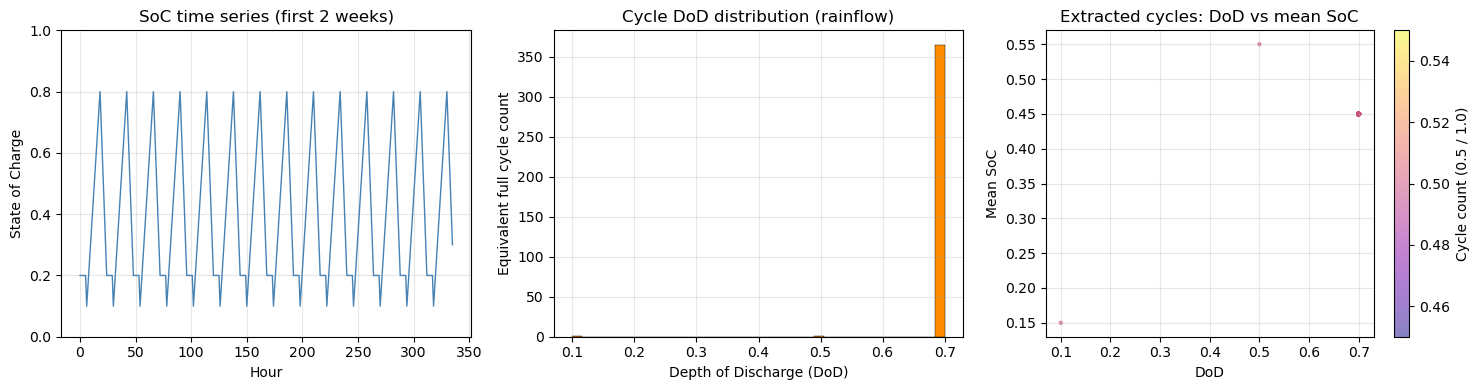

In [3]:
# Synthetic daily-cycle SoC pattern (1 cycle/day, DoD ~ 0.7)
hours_per_year = 8760  # number of hourly timesteps in one year
h = np.arange(hours_per_year)  # integer hour index 0..8759
hod = h % 24  # hour-of-day (0..23), used to build the daily charge/discharge pattern
SoC_daily = np.where(
    (hod >= 6) & (hod < 18),                           # charging (solar)
    0.1 + 0.7 * (hod - 6) / 12,                        # ramps from 0.1 to 0.8 during daylight
    np.where(hod >= 18, 0.8 - 0.6 * (hod - 18) / 6,   # discharging (evening): ramps 0.8→0.2
             0.2))                                      # overnight flat hold at 0.2

# Run rainflow cycle extraction on the synthetic SoC signal
rf_DoD, rf_SoC, rf_count, rf_i_start, rf_df = RFcount(SoC_daily)
# rf_DoD    — depth of discharge for each extracted cycle (0..1)
# rf_SoC    — mean SoC for each cycle (0..1)
# rf_count  — cycle weight: 1.0 = full cycle, 0.5 = half cycle
# rf_i_start — index of cycle start in the original SoC array
# rf_df     — full DataFrame with all five rainflow columns
print(f'Total cycles extracted : {len(rf_DoD)}')
print(f'Full cycles (count=1)  : {(rf_count == 1).sum()}')
print(f'Half cycles (count=0.5): {(rf_count == 0.5).sum()}')
print(f'DoD  range: {rf_DoD.min():.3f} – {rf_DoD.max():.3f}')
print(f'Mean SoC range: {rf_SoC.min():.3f} – {rf_SoC.max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # three side-by-side subplots

# SoC time series (first 2 weeks)
t2w = np.arange(2 * 7 * 24)  # 336 hourly timesteps = 2 weeks
axes[0].plot(t2w, SoC_daily[:len(t2w)], color='steelblue', lw=1)  # show first 2 weeks only
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('State of Charge')
axes[0].set_title('SoC time series (first 2 weeks)')
axes[0].set_ylim(0, 1); axes[0].grid(alpha=0.3)

# DoD histogram — weighted by cycle count so half-cycles contribute 0.5
axes[1].hist(rf_DoD, bins=40, weights=rf_count, color='darkorange',
             edgecolor='k', linewidth=0.3)  # each bin = equivalent full cycles at that DoD
axes[1].set_xlabel('Depth of Discharge (DoD)')
axes[1].set_ylabel('Equivalent full cycle count')
axes[1].set_title('Cycle DoD distribution (rainflow)')
axes[1].grid(alpha=0.3)

# Scatter: DoD vs mean SoC coloured by cycle count (0.5 or 1.0)
sc = axes[2].scatter(rf_DoD, rf_SoC, c=rf_count, cmap='plasma',
                      s=5, alpha=0.5)  # each point is one extracted cycle
plt.colorbar(sc, ax=axes[2], label='Cycle count (0.5 / 1.0)')  # colour = cycle weight
axes[2].set_xlabel('DoD'); axes[2].set_ylabel('Mean SoC')
axes[2].set_title('Extracted cycles: DoD vs mean SoC')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Total cycles extracted : 278
Full cycles (count=1)  : 169
Half cycles (count=0.5): 109
DoD  range: 0.000 – 0.950
Mean SoC range: 0.051 – 0.998


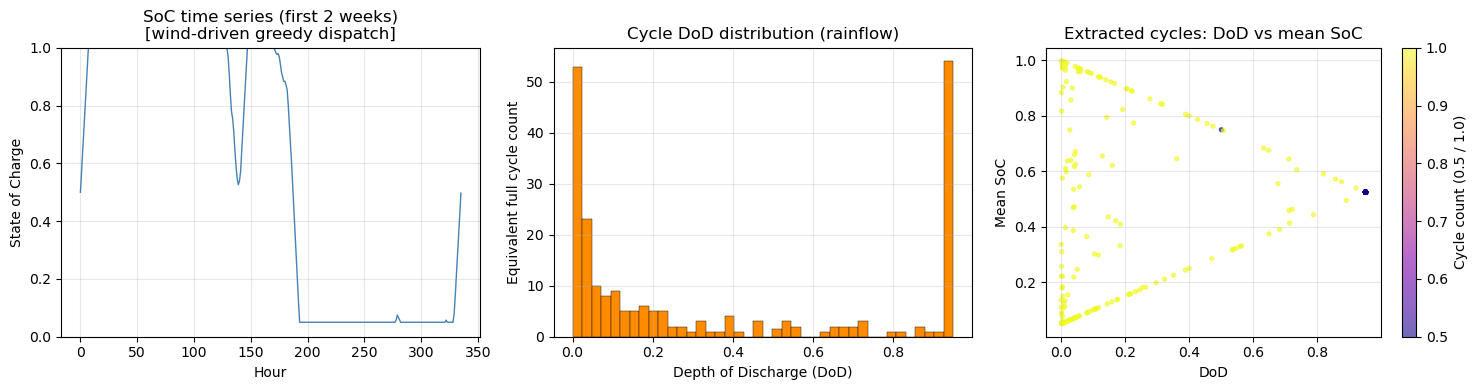

In [11]:
# Realistic SoC driven by France wind data (greedy wind-to-battery dispatch)
import xarray as xr
from hydesign.look_up_tables import lut_filepath  # path to NetCDF look-up tables (power curves etc.)

# Load 1-year hourly weather time series for a good French wind site
weather_rf = pd.read_csv(
    examples_filepath + 'Europe/GWA2/input_ts_France_good_wind.csv',
    index_col=0, parse_dates=True)
wst_rf = weather_rf.WS_150.values  # wind speed at 150 m hub height, m/s, shape (8760,)

# Single turbine power curve (sp=300 W/m2)
_genWT = xr.open_dataset(lut_filepath + 'genWT_v3.nc', engine='h5netcdf').interp(
    sp=300, kwargs={'fill_value': 0})  # interpolate power-curve LUT to specific power 300 W/m²
_ws_lut, _pc_lut = _genWT.ws.values, _genWT.pc.values; _genWT.close()  # wind-speed and power-coefficient arrays
wind_p = 0.95 * np.interp(wst_rf, _ws_lut, _pc_lut)   # fraction of rated (0-1); 0.95 = electrical efficiency factor

# Greedy dispatch: charge when wind > load, discharge otherwise
# E_max=4 h at rated power gives a realistic mix of shallow and deep cycles
load  = wind_p.mean()   # constant load set equal to mean wind power — keeps SoC balanced over the year
E_max = 4.0             # battery energy capacity in hours of rated power
P_max = 0.3             # max charge/discharge rate as fraction of rated power (C-rate limit)
eta   = 0.95            # one-way charge/discharge efficiency (round-trip ~ 0.90)

hours_per_year = len(wst_rf)  # number of timesteps (8760 for a non-leap year)
SoC_daily = np.zeros(hours_per_year)  # pre-allocate SoC array, shape (8760,)
SoC_daily[0] = 0.5  # start at 50% SoC
for t in range(1, hours_per_year):
    net   = wind_p[t] - load  # surplus (+) or deficit (-) power at this timestep
    delta = (min(net, P_max) * eta if net > 0 else max(net, -P_max) / eta) / E_max  # SoC change this hour
    SoC_daily[t] = np.clip(SoC_daily[t-1] + delta, 0.05, 1.0)  # enforce 5%-100% SoC bounds

# Extract rainflow cycles from the wind-driven SoC signal
rf_DoD, rf_SoC, rf_count, rf_i_start, rf_df = RFcount(SoC_daily)
# rf_DoD    — depth of discharge per cycle
# rf_SoC    — mean SoC per cycle
# rf_count  — 1.0 or 0.5 (full or half cycle)
# rf_i_start — timestep index of cycle start
print(f'Total cycles extracted : {len(rf_DoD)}')
print(f'Full cycles (count=1)  : {(rf_count == 1).sum()}')
print(f'Half cycles (count=0.5): {(rf_count == 0.5).sum()}')
print(f'DoD  range: {rf_DoD.min():.3f} – {rf_DoD.max():.3f}')
print(f'Mean SoC range: {rf_SoC.min():.3f} – {rf_SoC.max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # three side-by-side subplots

# SoC time series (first 2 weeks)
t2w = np.arange(2 * 7 * 24)  # 336 hours = 2 weeks
axes[0].plot(t2w, SoC_daily[:len(t2w)], color='steelblue', lw=1)  # show irregular wind-driven pattern
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('State of Charge')
axes[0].set_title('SoC time series (first 2 weeks)\n[wind-driven greedy dispatch]')
axes[0].set_ylim(0, 1); axes[0].grid(alpha=0.3)

# DoD histogram — weighted by cycle count
axes[1].hist(rf_DoD, bins=40, weights=rf_count, color='darkorange',
             edgecolor='k', linewidth=0.3)  # more spread vs. synthetic — real wind has varied DoD
axes[1].set_xlabel('Depth of Discharge (DoD)')
axes[1].set_ylabel('Equivalent full cycle count')
axes[1].set_title('Cycle DoD distribution (rainflow)')
axes[1].grid(alpha=0.3)

# Scatter: DoD vs mean SoC coloured by cycle count
sc = axes[2].scatter(rf_DoD, rf_SoC, c=rf_count, cmap='plasma',
                      s=8, alpha=0.6)  # each point = one extracted cycle
plt.colorbar(sc, ax=axes[2], label='Cycle count (0.5 / 1.0)')
axes[2].set_xlabel('DoD'); axes[2].set_ylabel('Mean SoC')
axes[2].set_title('Extracted cycles: DoD vs mean SoC')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Plot 2 — Stress factors in the linear degradation model

`Linear_Degfun` computes per-cycle degradation as a product of four stress factors (Xu et al., IEEE Trans. Smart Grid, 2016):

| Factor | Driven by | Physical meaning |
|---|---|---|
| $S_{DoD}$ | Depth of discharge | Deeper cycles cause disproportionately more wear |
| $S_{SoC}$ | Mean SoC per cycle | High SoC accelerates electrolyte oxidation |
| $S_T$ | Temperature | Heat accelerates Li-ion side reactions |
| $S_{time}$ | Cycle start time | Calendar ageing (time since manufacture) |

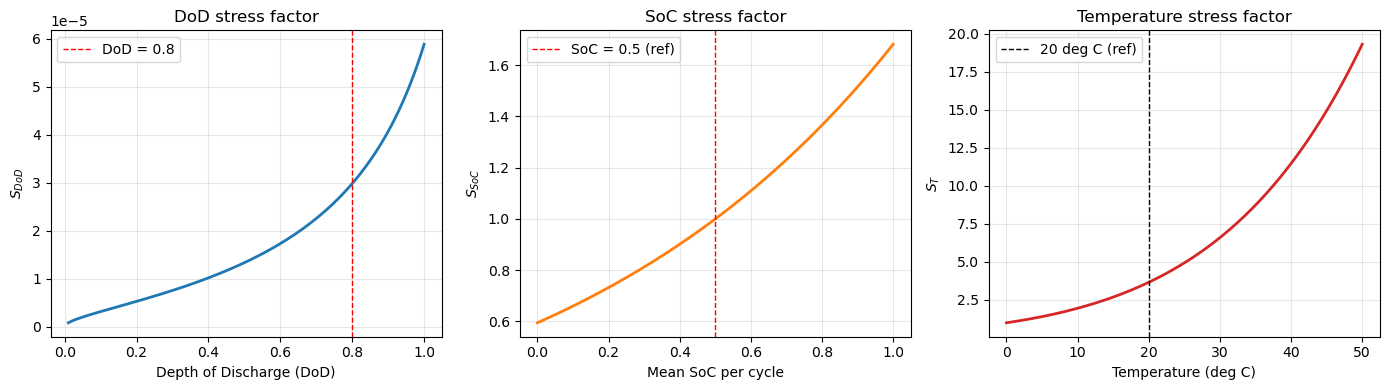

At DoD=0.8 : S_DoD = 0.0000
At SoC=0.5 : S_SoC = 1.0000
At T=25 C  : S_T   = 4.9352


In [9]:
# These are the fitted empirical parameters from the paper:

# Xu et al., "Modeling of Lithium-Ion Battery Degradation for Cell Life Assessment", IEEE Transactions on Smart Grid, 2016

# DoD stress coefficients (Equation 4 in Xu et al.)
kdelta1, kdelta2, kdelta3 = 1.4e5, -5.01e-1, -1.23e5
# SoC stress coefficient and reference SoC at which S_SoC = 1
ksigma, sigma_ref = 1.04, 0.5
# Temperature stress coefficient and reference temperature (20 deg C in Kelvin)
kT, Tref = 6.93e-2, 293.15

dod_v  = np.linspace(0.01, 1.0, 200)  # DoD sweep from 1% to 100% (avoid 0 to prevent division issues)
soc_v  = np.linspace(0.0,  1.0, 200)  # mean SoC sweep from 0 to 100%
temp_v = np.linspace(0, 50, 200)       # temperature sweep in Celsius

# Compute the three stress factors analytically over their respective sweeps
S_DoD  = (kdelta1 * dod_v ** kdelta2 + kdelta3) ** (-1)  # DoD stress: power-law, normalised to ~1 at DoD=0.8
S_SoC  = np.exp(ksigma * (soc_v - sigma_ref))            # SoC stress: exponential, =1 at sigma_ref=0.5
S_T    = np.where(temp_v + Tref > Tref,
                   np.exp(kT * temp_v * Tref / (temp_v + Tref)), 1.0)  # temp stress: =1 below 20°C, exponential above

fig, axes = plt.subplots(1, 3, figsize=(14, 4))  # three panels, one per stress factor

# Panel 1: DoD stress factor — steeper = deeper cycles are much more damaging
axes[0].plot(dod_v, S_DoD, 'tab:blue', lw=2)
axes[0].axvline(0.8, color='r', ls='--', lw=1, label='DoD = 0.8')  # highlight typical operating point
axes[0].set_xlabel('Depth of Discharge (DoD)'); axes[0].set_ylabel('$S_{DoD}$')
axes[0].set_title('DoD stress factor'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2: SoC stress factor — higher mean SoC accelerates electrolyte oxidation
axes[1].plot(soc_v, S_SoC, 'tab:orange', lw=2)
axes[1].axvline(0.5, color='r', ls='--', lw=1, label='SoC = 0.5 (ref)')  # reference point where S_SoC = 1
axes[1].set_xlabel('Mean SoC per cycle'); axes[1].set_ylabel('$S_{SoC}$')
axes[1].set_title('SoC stress factor'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Panel 3: Temperature stress factor — only active above Tref (20 deg C), flat below
axes[2].plot(temp_v, S_T, 'tab:red', lw=2)
axes[2].axvline(20, color='k', ls='--', lw=1, label='20 deg C (ref)')  # Tref = 293.15 K = 20 deg C
axes[2].set_xlabel('Temperature (deg C)'); axes[2].set_ylabel('$S_T$')
axes[2].set_title('Temperature stress factor'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
# Print spot-check values to verify the curves are correctly calibrated
print('At DoD=0.8 : S_DoD =', f'{np.interp(0.8, dod_v, S_DoD):.4f}')
print('At SoC=0.5 : S_SoC =', f'{np.interp(0.5, soc_v, S_SoC):.4f}')  # should be 1.0 (reference point)
print('At T=25 C  : S_T   =', f'{np.interp(25, temp_v, S_T):.4f}')

## Plot 3 — State of Health evolution over 25-year lifetime

`degradation` converts the cumulative linear loss `LLoC` into a non-linear **State of Health (SoH = 1 − LoC)** curve with two regimes:

- Above SoH ≈ 0.92: slow, approximately linear degradation
- Below SoH ≈ 0.92: accelerated 'knee-point' degradation

The plot sweeps three operating conditions (shallow/medium/deep daily cycling) to show their effect on lifetime.

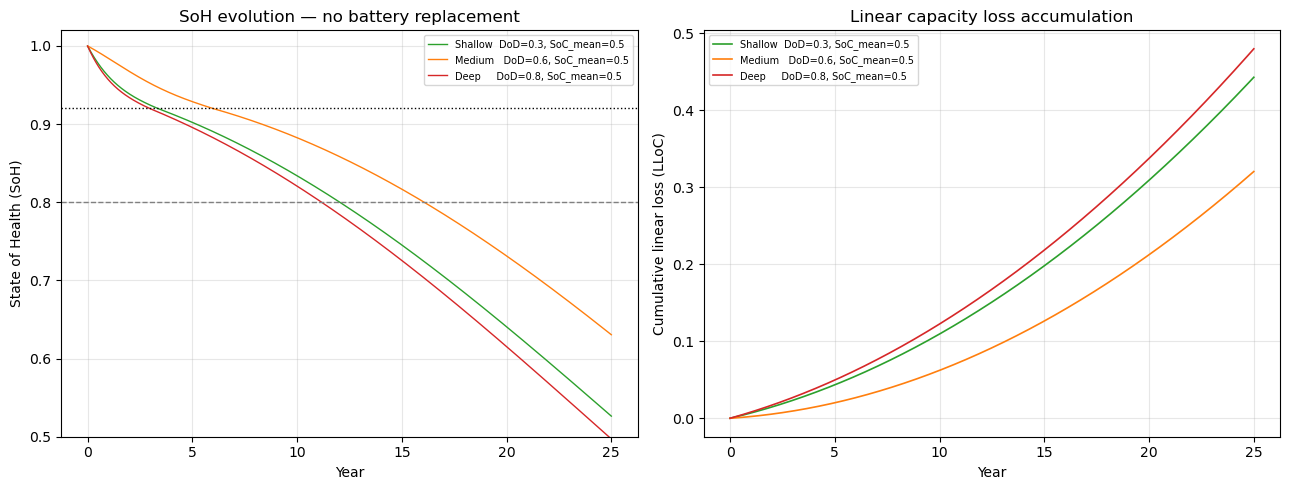

In [10]:
life_y   = 25      # simulation lifetime in years
N_annual = 8760    # timesteps per year (hourly)
N_life   = life_y * N_annual  # total timesteps over the full 25-year life
h_life   = np.arange(N_life)  # integer hour index 0..N_life-1, used as time axis
avr_tem  = 20 + 273.15   # average battery temperature in Kelvin (20 deg C = 293.15 K)

# Each scenario is a tuple: (display label, SoC_min, SoC_max, plot colour)
# soc_min/soc_max define the daily charge/discharge envelope; DoD = soc_max - soc_min
scenarios = [
    ('Shallow  DoD=0.3, SoC_mean=0.5',  0.10, 0.85, 'tab:green'),   # DoD ~ 0.75, shallow cycling
    ('Medium   DoD=0.6, SoC_mean=0.5',  0.30, 0.60, 'tab:orange'),  # DoD ~ 0.30, medium cycling
    ('Deep     DoD=0.8, SoC_mean=0.5',  0.10, 0.90, 'tab:red'),     # DoD ~ 0.80, deep cycling
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # left = SoH, right = cumulative LLoC

for label, soc_min, soc_max, col in scenarios:
    hod = np.arange(N_annual) % 24  # hour-of-day index for one year
    dod_i = soc_max - soc_min       # peak-to-peak depth of discharge for this scenario
    # Build one-year SoC pattern: ramp up during day, ramp down evening, flat overnight
    SoC_i = np.where((hod >= 6) & (hod < 18),
                      soc_min + dod_i * (hod - 6) / 12,        # charging phase
                      np.where(hod >= 18, soc_max - dod_i * (hod - 18) / 6, soc_min))  # discharge / flat
    SoC_ext = np.tile(SoC_i, life_y)  # repeat 1-year pattern across full 25-year lifetime
    # Run rainflow cycle extraction on the full 25-year SoC signal
    rf_DoD_i, rf_SoC_i, rf_cnt_i, rf_t_i, _ = RFcount(SoC_ext)
    # Run non-linear degradation model: LoC = Loss of Capacity, LoC1 = pre-knee LoC, LLoC = linear cumulative
    LoC_i, LoC1_i, _ = degradation(rf_DoD_i, rf_SoC_i, rf_cnt_i, rf_t_i, avr_tem)
    # Interpolate per-cycle SoH onto a regular hourly time axis for plotting
    SoH_i = np.interp(h_life, rf_t_i, 1 - LoC_i)  # SoH = 1 - LoC; interpolated to hour grid
    yr_axis = h_life / N_annual  # convert hours to years for x-axis
    axes[0].plot(yr_axis, SoH_i, color=col, lw=1, label=label)  # SoH trajectory vs time
    # Re-run degradation to also get LLoC (cumulative linear loss) for the right panel
    _, _, LLoC_i = degradation(rf_DoD_i, rf_SoC_i, rf_cnt_i, rf_t_i, avr_tem)
    axes[1].plot(rf_t_i / N_annual, LLoC_i, color=col, lw=1.2, label=label)  # LLoC at each cycle event

for ax in axes:
    ax.set_xlabel('Year')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
axes[0].axhline(0.92, color='k', ls=':', lw=1, label='Knee point (0.92)')  # SoH where degradation accelerates
axes[0].axhline(0.80, color='gray', ls='--', lw=1, label='Common min LoH (0.80)')  # typical replacement threshold
axes[0].set_ylabel('State of Health (SoH)'); axes[0].set_ylim(0.5, 1.02)
axes[0].set_title('SoH evolution — no battery replacement')
axes[1].set_ylabel('Cumulative linear loss (LLoC)')  # LLoC drives the non-linear LoC via the alpha/beta model
axes[1].set_title('Linear capacity loss accumulation')
plt.tight_layout(); plt.show()

## Plot 4 — Battery replacement logic

`battery_replacement` automatically replaces the battery each time SoH falls below `min_LoH`, using a fresh cell and restarting the degradation clock.  
The plot compares allowing **1, 2, or 3** replacement batteries at `min_LoH = 0.70`.

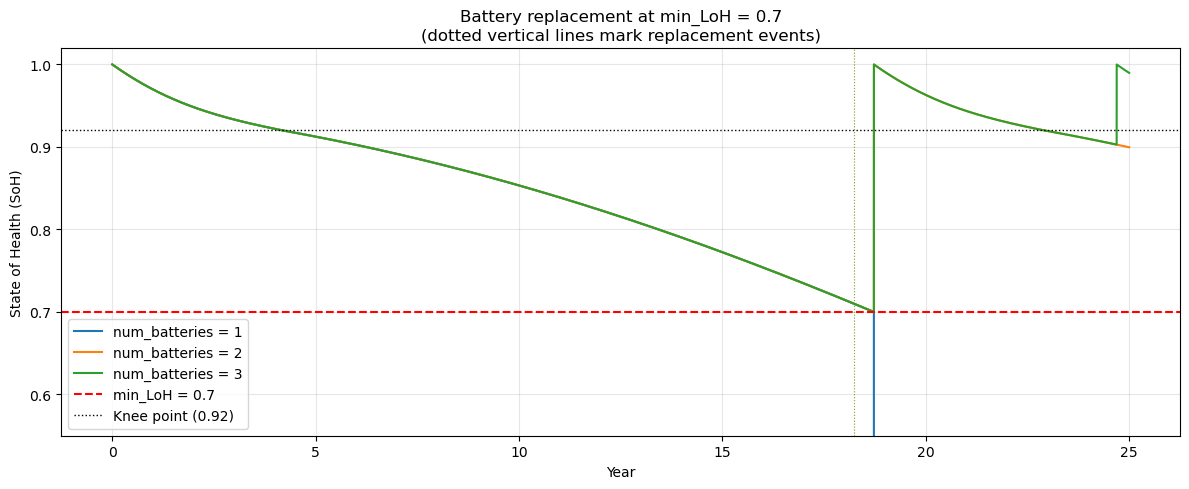

  num_batteries  |  SoH at year 25
  ----------    |  ---------------
  1             |  0.000
  2             |  0.900
  3             |  0.990


In [6]:
# Build SoC time series: medium cycling, 25-year lifetime
# hod and life_y are carried over from the previous cell (Plot 3)
SoC_med = np.where((hod >= 6) & (hod < 18),
                    0.2 + 0.6 * (hod - 6) / 12,                    # charge ramp: 0.2→0.8 during daylight
                    np.where(hod >= 18, 0.8 - 0.5 * (hod - 18) / 6, 0.2))  # discharge ramp 0.8→0.3, then flat
SoC_life = np.tile(SoC_med, life_y)  # repeat 1-year pattern for the full 25-year lifetime
# Run rainflow on the full 25-year SoC signal
rf_D, rf_S, rf_C, rf_T, _ = RFcount(SoC_life)
# rf_D — DoD per cycle; rf_S — mean SoC per cycle; rf_C — cycle count; rf_T — cycle start timestep
avr_tem = 20 + 273.15  # average temperature in Kelvin (20 deg C)
min_LoH = 0.70          # replace battery when SoH falls below 70% (Loss of Health threshold)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']  # one colour per battery-count scenario
for n_bat, col in zip([1, 2, 3], colors):
    # Run degradation model allowing n_bat total batteries (1 = no replacement)
    LoC_n, ind_q, _ = battery_replacement(
        rf_D, rf_S, rf_C, rf_T, avr_tem, min_LoH,
        n_steps_in_LoH=30,      # number of SoH quantile steps used internally for replacement indexing
        num_batteries=n_bat)    # total number of batteries over the lifetime (including replacements)
    # ind_q — list of cycle indices at each SoH quantile step (used to locate replacement events)
    SoH_n = np.interp(h_life, rf_T, 1 - LoC_n)  # interpolate to hourly grid; SoH = 1 - LoC
    ax.plot(h_life / N_annual, SoH_n, color=col, lw=1.5,
            label=f'num_batteries = {n_bat}')  # SoH trajectory over 25 years
    # Mark replacement events as vertical dotted lines at the point SoH hits min_LoH
    replace_times = [rf_T[i] / N_annual for i in ind_q
                     if i < len(rf_T) and 1 - LoC_n[i] <= min_LoH + 0.01]  # small tolerance to catch exact threshold
    for rt in replace_times[:n_bat-1]:  # only n_bat-1 replacements possible for n_bat batteries
        ax.axvline(rt, color=col, ls=':', lw=0.8, alpha=0.6)  # dotted line at each replacement year

ax.axhline(min_LoH, color='red', ls='--', lw=1.5, label=f'min_LoH = {min_LoH}')  # replacement trigger level
ax.axhline(0.92, color='k', ls=':', lw=1, label='Knee point (0.92)')  # knee where degradation accelerates
ax.set_xlabel('Year'); ax.set_ylabel('State of Health (SoH)')
ax.set_title(f'Battery replacement at min_LoH = {min_LoH}\n'
             '(dotted vertical lines mark replacement events)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0.55, 1.02)
plt.tight_layout(); plt.show()

# Summary table: final SoH at year 25 for each battery count
print(f'  num_batteries  |  SoH at year 25')
print(f'  {"----------":14s}|  ---------------')
for n_bat in [1, 2, 3]:
    LoC_n, _, _ = battery_replacement(rf_D, rf_S, rf_C, rf_T, avr_tem,
                                       min_LoH, num_batteries=n_bat)  # re-run to get fresh LoC
    SoH_end = float(np.interp(N_life - 1, rf_T, 1 - LoC_n))  # SoH at the last timestep of year 25
    print(f'  {n_bat:<14d}|  {SoH_end:.3f}')

## Plot 5 — Thermal capacity loss

`thermal_loss_of_storage` applies a **temperature-dependent capacity de-rating** on top of the cycle-ageing SoH.  
Below ~15°C lithium-ion batteries temporarily lose usable capacity (Lv et al., *Energies*, 2021).  

This is a **reversible** effect (capacity returns when temperature rises), unlike the permanent degradation from cycling.

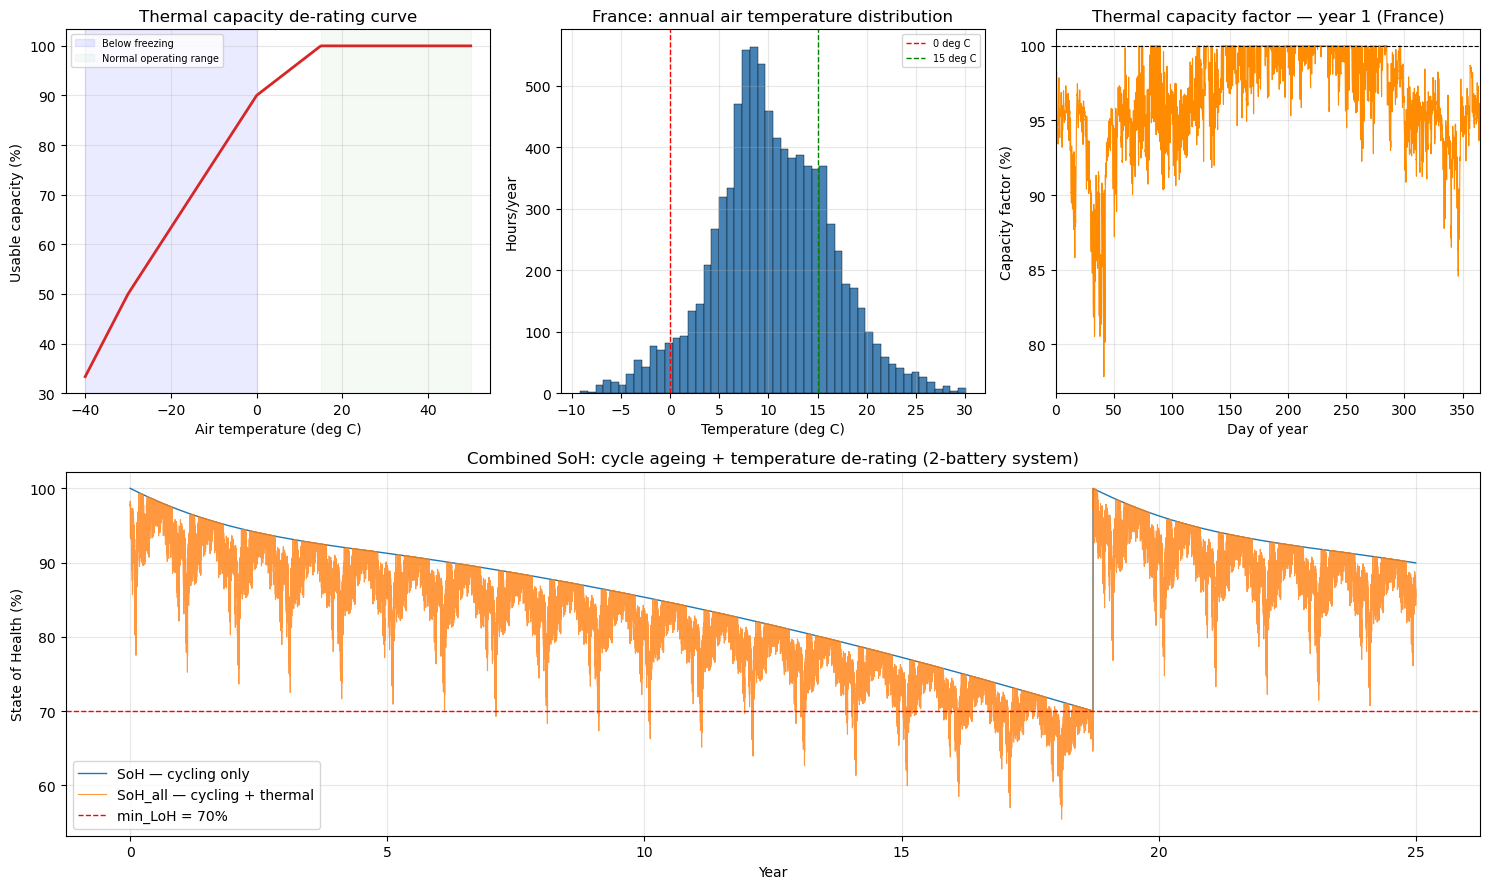

Min thermal capacity factor : 77.8%
Hours/year below 15 deg C   : 6857 h  (78% of year)
Mean SoH_all at year 25     : 87.2%


In [7]:
# Load France weather data and extend to lifetime
# Re-uses examples_filepath and life_y/N_annual/N_life/h_life from earlier cells
weather = pd.read_csv(
    examples_filepath + 'Europe/GWA2/input_ts_France_good_wind.csv',
    index_col=0, parse_dates=True)
temp_C_yr  = (weather.temp_air_1 - 273.15).values   # convert from Kelvin to Celsius; 1-year hourly air temp
temp_C_life = np.tile(temp_C_yr, life_y)             # tile to cover the full 25-year simulation period

# Apply piecewise-linear thermal de-rating: returns values in [0, 1]
# Values < 1 mean the battery temporarily loses usable capacity due to cold temperatures
therm_factor_life = thermal_loss_of_storage(temp_C_life)  # shape (N_life,), values 0..1

# SoH from Plot 4 (medium cycling, 2 batteries) — re-run to ensure availability in this cell
LoC_2, _, _ = battery_replacement(rf_D, rf_S, rf_C, rf_T, avr_tem,
                                   min_LoH, num_batteries=2)  # LoC for medium cycling with 1 replacement
SoH_cycle = np.interp(h_life, rf_T, 1 - LoC_2)       # cycle-only SoH on hourly grid
SoH_all   = therm_factor_life * SoH_cycle              # combined SoH: multiply thermal factor by cycle SoH

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig)  # 2-row, 3-column layout; bottom row spans all columns

# Panel (0,0): thermal de-rating curve — shows the piecewise-linear lookup table
ax0 = fig.add_subplot(gs[0, 0])
T_range = np.linspace(-40, 50, 300)  # temperature sweep for curve display
ax0.plot(T_range, thermal_loss_of_storage(T_range) * 100, 'tab:red', lw=2)  # capacity as percentage
ax0.axvspan(-40, 0,  alpha=0.08, color='blue',  label='Below freezing')       # below 0 deg C: significant de-rating
ax0.axvspan(15, 50,  alpha=0.04, color='green', label='Normal operating range')  # above 15 deg C: no de-rating
ax0.set_xlabel('Air temperature (deg C)')
ax0.set_ylabel('Usable capacity (%)')
ax0.set_title('Thermal capacity de-rating curve')
ax0.legend(fontsize=7); ax0.grid(alpha=0.3)

# Panel (0,1): annual temperature histogram — shows how many hours are in each temperature band
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(temp_C_yr, bins=50, color='steelblue', edgecolor='k', linewidth=0.3)  # hourly counts per temperature bin
ax1.axvline(0, color='r', ls='--', lw=1, label='0 deg C')    # below this: de-rating begins strongly
ax1.axvline(15, color='g', ls='--', lw=1, label='15 deg C')  # below this: partial de-rating
ax1.set_xlabel('Temperature (deg C)'); ax1.set_ylabel('Hours/year')
ax1.set_title('France: annual air temperature distribution')
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# Panel (0,2): thermal factor time series for year 1
ax2 = fig.add_subplot(gs[0, 2])
t_yr = np.arange(N_annual)  # hour indices 0..8759 for one year
ax2.plot(t_yr / 24, therm_factor_life[:N_annual] * 100, 'darkorange', lw=0.8)  # capacity % by day-of-year
ax2.axhline(100, color='k', ls='--', lw=0.8)  # reference: 100% = no thermal de-rating
ax2.set_xlabel('Day of year'); ax2.set_ylabel('Capacity factor (%)')
ax2.set_title('Thermal capacity factor — year 1 (France)')
ax2.set_xlim(0, 365); ax2.grid(alpha=0.3)

# Panel (1, 0:3): full 25-year SoH comparison — cycle-only vs combined
ax3 = fig.add_subplot(gs[1, :])  # span all 3 columns for wide time-series view
yr_ax = h_life / N_annual        # convert hours to years for x-axis
ax3.plot(yr_ax, SoH_cycle * 100, 'tab:blue',   lw=1,   label='SoH — cycling only')         # permanent degradation only
ax3.plot(yr_ax, SoH_all   * 100, 'tab:orange', lw=0.8, label='SoH_all — cycling + thermal', alpha=0.8)  # includes reversible thermal loss
ax3.axhline(min_LoH * 100, color='red', ls='--', lw=1, label=f'min_LoH = {min_LoH*100:.0f}%')  # replacement threshold
ax3.set_xlabel('Year')
ax3.set_ylabel('State of Health (%)')
ax3.set_title('Combined SoH: cycle ageing + temperature de-rating (2-battery system)')
ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Summary statistics for the thermal de-rating analysis
min_therm = therm_factor_life.min() * 100    # worst-case thermal capacity loss as a percentage
hrs_below_15 = (temp_C_yr < 15).sum()        # hours per year when de-rating is active (T < 15 deg C)
print(f'Min thermal capacity factor : {min_therm:.1f}%')
print(f'Hours/year below 15 deg C   : {hrs_below_15} h  ({hrs_below_15/N_annual*100:.0f}% of year)')
print(f'Mean SoH_all at year 25     : {SoH_all[-N_annual:].mean()*100:.1f}%')